In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
pd.set_option("display.width", 200)

## Importando

In [2]:
clusters = pd.read_csv(RAIZ / "data/processed/clusters_risco.csv", index_col=0)
metadata = pd.read_csv(RAIZ / "data/raw/metadata_recorte.csv", index_col=0)
df = clusters.join(metadata.drop(columns=["Species"]), how="left")

print(df.shape)
df.head()

(2226, 12)


,cluster,conjunto,perfil,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,,,,
GCA_029076165.1,2,treino,C2: carbapenemase serina (plasm. 61%),Klebsiella pneumoniae,urine,2021.0,Brazil,SAMN33566985,NaN,NaN,Urinary,Critical
GCF_001420335.1,2,treino,C2: carbapenemase serina (plasm. 61%),Acinetobacter baumannii,rectal swab,2012.0,"Hospital das Clinicas, Sao Paulo",SAMN04196794,SP,Sul,Gastrointestinal,Critical
GCA_002304205.1,1,treino,C1: ESBL sem carbapenemase,Klebsiella pneumoniae,rectal swab,2011.0,Brazil,SAMN07595147,NaN,NaN,Gastrointestinal,Critical
GCA_031011085.1,3,treino,C3: carbapenemase serina + ESBL (plasm. 96%),Klebsiella pneumoniae,Surveillance Swab,2019.0,Brazil,SAMN36785147,NaN,NaN,Other,Critical
GCA_031630615.1,0,treino,C0: MBL + ESBL (plasm. 80%),Enterobacter hormaechei,blood,2020.0,Sao Paulo,SAMN30951027,SP,Sul,Blood,Critical


In [3]:
print(df.groupby("cluster")["perfil"].first().to_string())

cluster
0                          C0: MBL + ESBL (plasm. 80%)
1                           C1: ESBL sem carbapenemase
2                C2: carbapenemase serina (plasm. 61%)
3         C3: carbapenemase serina + ESBL (plasm. 96%)
4    C4: carbapenemase serina + metilase 16S (plasm...
5                C5: sem mecanismo principal adquirido


In [4]:
# rótulo curto pro eixo dos heatmaps
ROTULO = {
    0: "C0 MBL+ESBL",
    1: "C1 ESBL",
    2: "C2 carb.",
    3: "C3 carb. +ESBL",
    4: "C4 carb. +metilase 16S",
    5: "C5 sem mecanismo",
}

df["cl"] = pd.Categorical(df["cluster"].map(ROTULO), categories=list(ROTULO.values()), ordered=True)
print(f"\n{len(df)} genomas")
df["cl"].value_counts().sort_index()


2226 genomas


C0 MBL+ESBL               219
C1 ESBL                   315
C2 carb.                  491
C3 carb. +ESBL            438
C4 carb. +metilase 16S    297
C5 sem mecanismo          466
Name: cl, dtype: int64

In [5]:
df_train = pd.read_csv("data/processed/df_estruturada/df_train_risco.csv", index_col=0).join(df[["cluster"]])
df_valid  = pd.read_csv("data/processed/df_estruturada/df_valid_risco.csv",  index_col=0).join(df[["cluster"]])
df_test  = pd.read_csv("data/processed/df_estruturada/df_test_risco.csv",  index_col=0).join(df[["cluster"]])

## Lógica

```python
def classify(self, modelo: str, n_splits: int = 5) -> tuple[pd.DataFrame, np.ndarray]:
    construtores = {
        "knn": self.__knn_classify, "svm": self.__svm_classify,
        "rf": self.__rf_classify, "gbm": self.__gbm_classify,
        "nb": self.__nb_classify, "nn": self.__nn_classify,
    }
    if modelo not in construtores:
        raise ValueError(f"modelo {modelo!r} desconhecido -- use um de {list(construtores)}")

    estimator, param_grid = construtores[modelo]()
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    grid_search = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=cv,
                                scoring=self.scoring, n_jobs=-1)

    grid_search.fit(self.X, self.y)
    self.modelos_[modelo] = grid_search.best_estimator_

    self.__metricas_pontuais(grid_search=grid_search)
    y_true, y_pred, conjunto = self.__avaliar(grid_search=grid_search, cv=cv)
    self.__matrix_confusao(y_true, y_pred, conjunto)
    self.__variaveis_selecionadas(grid_search=grid_search)

    return self.__retornar_metricas(y_true, y_pred, conjunto), y_pred
```

In [6]:
construtores = {
        "knn": "self.__knn_classify", 
        "svm": "self.__svm_classify",
        "rf": "self.__rf_classify",
    }

construtores["knn"] # () pra chamar a função depois

'self.__knn_classify'

In [7]:
# __knn_classify(self) -> tuple[Pipeline, dict]:

# Pipeline: tuplas com preprocessor, var_threshold, feature_selection, knn (KNeighborsClassifier())
# dict: hiperparametros
estimator, param_grid = construtores["knn"]

ValueError: too many values to unpack (expected 2)

In [ ]:
grid_search = GridSearchCV(estimator=estimator,   # Pipeline
                           param_grid=param_grid, # param_grid
                           cv=cv,                 # divide os dados em n_splits
                           scoring=self.scoring,  
                           n_jobs=-1) # todas as cpus disponíveis kk

In [ ]:
# para cada combinação de param_grid, treina e avalia com cv
# guarda o best_estimator_ (o pipeline inteiro, já reajustado nos dados completos com os melhores parâmetros).

grid_search.fit(self.X, self.y)

# salva o melhor pipeline pra usar depois "self.modelos_["rf"].predict(df_valid)"
self.modelos_[modelo] = grid_search.best_estimator_

In [ ]:
# Métodos de relatório

## print de grid_search.best_params_ e grid_search.best_score_
self.__metricas_pontuais(grid_search=grid_search)

## Prediz em dados não de treino
## return self.y_test, grid_search.best_estimator_.predict(self.X_test)
y_true, y_pred, conjunto = self.__avaliar(grid_search=grid_search, cv=cv)

## Matriz de confusão entre o y predito e verdadeiro
self.__matrix_confusao(y_true, y_pred, conjunto)

## retorna quais colunas sobreviveram ao feature selection/var_threshold
self.__variaveis_selecionadas(grid_search=grid_search)

## Retorna um pd.DataFrame com métricas
return self.__retornar_metricas(y_true, y_pred, conjunto)
pd.DataFrame({
    "Conjunto": [conjunto],
    "Acurácia": [accuracy_score(y_true, y_pred)],
    "Acurácia balanceada": [balanced_accuracy_score(y_true, y_pred)],
    "Precision (weighted)": [precision_score(...)],}
    # a precisão média do modelo, ponderada pelo tamanho de cada classe

## Treinando

In [8]:
from notebooks.src.classifier import Classifier

print(df_train.shape)

clf = Classifier(df_train, 
                 target="cluster", 
                 df_test=df_valid, 
                 descartar=["Species"])

    # self.target = target
    # self.scoring = scoring
    # self.descartar = [c for c in descartar if c in df.columns]
    # self.X = df.drop(columns=[target, *self.descartar])
    # self.y = df[target]
    # self.X_test = None if df_test is None else df_test[self.X.columns]
    # self.y_test = None if df_test is None else df_test[target]
    # self.modelos_ = {}  # só existe depois do .fit

(1558, 17)


### RF

--- Treinando rf (1558 amostras, 15 features) ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'rf__criterion': 'gini', 'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 50, 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.9961


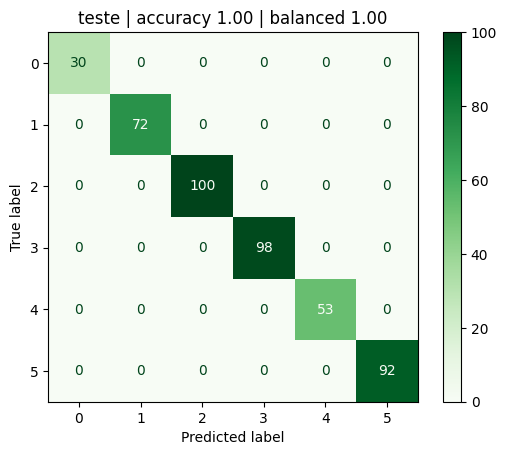


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       1.00      1.00      1.00        53
           5       1.00      1.00      1.00        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

In [ ]:
# "knn", "svm", "rf", "gbm", "nb", "nn"
# classify(self, modelo: str, n_splits: int = 5) -> tuple[pd.DataFrame, np.ndarray]
metricas, y_pred = clf.classify("rf")        

# ta hardcoded "teste", mas no caso é df_valid

In [ ]:
print("10 primeiros valores preditos em y_pred")
print(y_pred[:10]) 

10 primeiros valores preditos em y_pred
[1 5 4 1 1 2 5 3 2 3]


In [ ]:
metricas

,Conjunto,Acurácia,Acurácia balanceada,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro)
0,teste,1.0,1.0,1.0,1.0,1.0,1.0


### Loop por todos os modelos (train + valid)
- Montando uma tabela final de metricas concatenadas com os hiperparametros

--- Treinando knn (1558 amostras, 15 features) ---

--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform', 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.9925


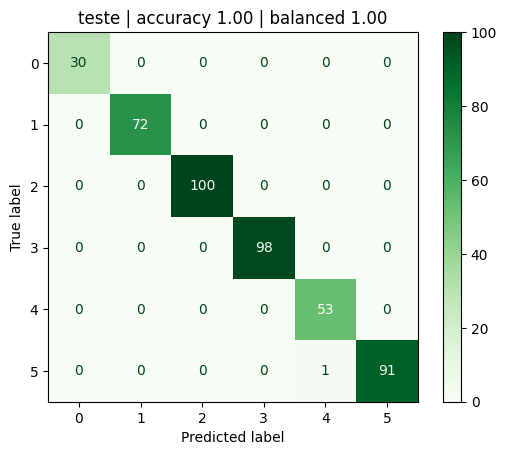


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       0.98      1.00      0.99        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

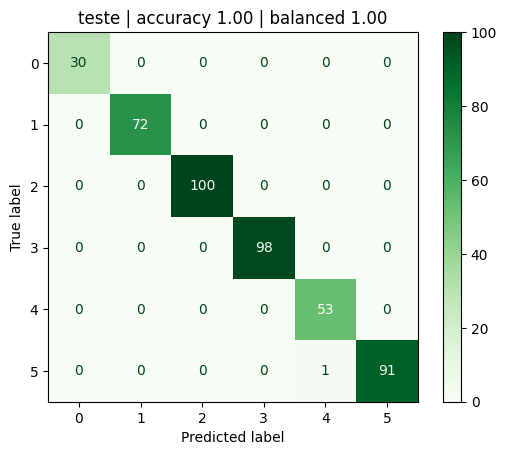


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       0.98      1.00      0.99        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

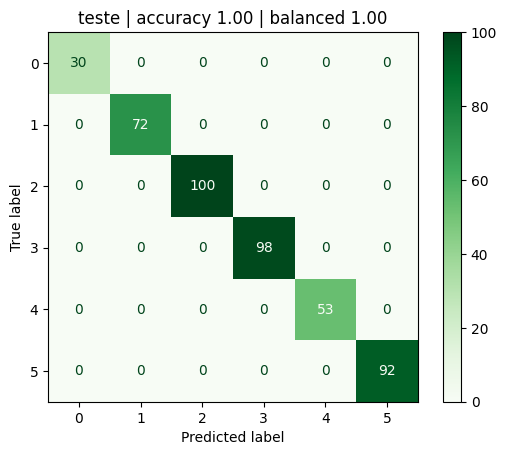


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       1.00      1.00      1.00        53
           5       1.00      1.00      1.00        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

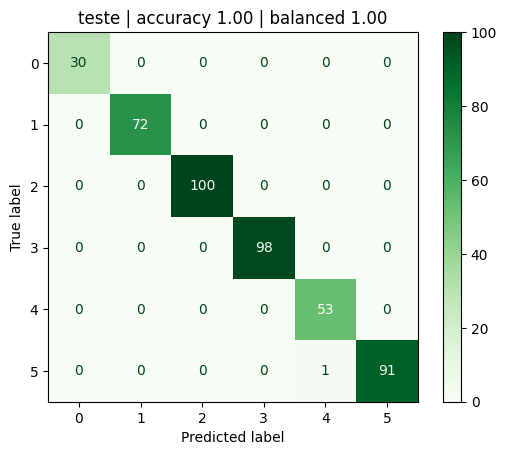


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       0.98      1.00      0.99        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

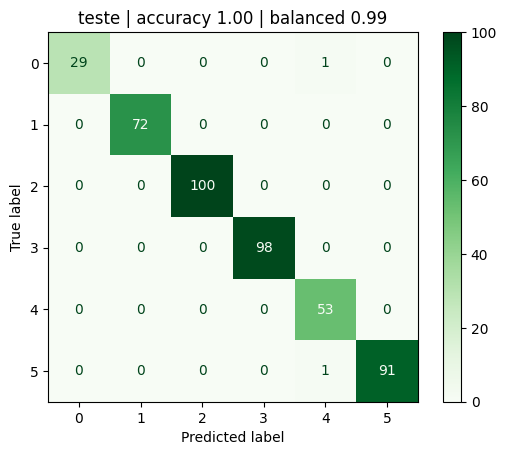


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00        98
           4       0.96      1.00      0.98        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       0.99      0.99      0.99       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

/usr/local/lib/python3.10/site-packages/sklearn/model_selection/_search.py:409: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.array(param_list)



--- Melhores Resultados do Grid Search ---
Melhores hiperparâmetros: {'feature_selection__k': 'all', 'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,), 'mlp__solver': 'lbfgs', 'var_threshold__threshold': 0.0001}
Melhor balanced_accuracy (CV): 0.9977


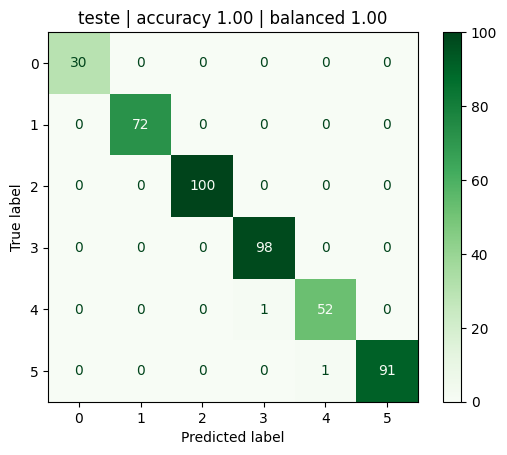


Classification Report (teste):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        72
           2       1.00      1.00      1.00       100
           3       0.99      1.00      0.99        98
           4       0.98      0.98      0.98        53
           5       1.00      0.99      0.99        92

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

Total de variáveis originais pré-processadas: 15
Total de variáveis após VarianceThreshold:    15
Total de variáveis selecionadas no modelo:    15

--- Lista das Variáveis Selecionadas ---
1. num__has_carbapenemase
2. num__has_mbl
3. num__has_carbapenemase_serina
4. num__n_carbapenemases
5. num__has_esbl
6. num__has_ampc_adquirida
7. num__n_bl_adquiridas
8. num__has_16s_metilase
9. num__n_ame
10. num__has_mcr
11. num__has

,Conjunto,Acurácia,Acurácia balanceada,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),modelo,melhores_hiperparametros
0,teste,0.9978,0.9982,0.9978,0.9978,0.9978,0.9975,knn,"{'feature_selection__k': 'all', 'knn__metric':..."
1,teste,0.9978,0.9982,0.9978,0.9978,0.9978,0.9975,svm,"{'feature_selection__k': 'all', 'svm__C': 1, '..."
2,teste,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,rf,"{'feature_selection__k': 'all', 'rf__criterion..."
3,teste,0.9978,0.9982,0.9978,0.9978,0.9978,0.9975,gbm,"{'feature_selection__k': 'all', 'gb__learning_..."
4,teste,0.9955,0.9926,0.9957,0.9955,0.9955,0.9932,nb,"{'feature_selection__k': 'all', 'nb__var_smoot..."
5,teste,0.9955,0.9950,0.9955,0.9955,0.9955,0.9951,nn,"{'feature_selection__k': 'all', 'mlp__activati..."


In [9]:
modelos = ["knn", "svm", "rf", "gbm", "nb", "nn"]
resultados = []

for modelo in modelos:
    metricas, y_pred = clf.classify(modelo)
    metricas["modelo"] = modelo
    metricas["melhores_hiperparametros"] = str(clf.melhores_parametros_[modelo])
    resultados.append(metricas)

report_final = pd.concat(resultados, ignore_index=True)
report_final

In [10]:
report_final

,Conjunto,Acurácia,Acurácia balanceada,Precision (weighted),Recall (weighted),F1 (weighted),F1 (macro),modelo,melhores_hiperparametros
0,teste,0.9978,0.9982,0.9978,0.9978,0.9978,0.9975,knn,"{'feature_selection__k': 'all', 'knn__metric':..."
1,teste,0.9978,0.9982,0.9978,0.9978,0.9978,0.9975,svm,"{'feature_selection__k': 'all', 'svm__C': 1, '..."
2,teste,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,rf,"{'feature_selection__k': 'all', 'rf__criterion..."
3,teste,0.9978,0.9982,0.9978,0.9978,0.9978,0.9975,gbm,"{'feature_selection__k': 'all', 'gb__learning_..."
4,teste,0.9955,0.9926,0.9957,0.9955,0.9955,0.9932,nb,"{'feature_selection__k': 'all', 'nb__var_smoot..."
5,teste,0.9955,0.9950,0.9955,0.9955,0.9955,0.9951,nn,"{'feature_selection__k': 'all', 'mlp__activati..."


## Teste

### Random Forest

In [11]:
X_test_final = df_test[clf.X.columns]
y_test_final = df_test["cluster"]

y_pred_test = clf.modelos_["rf"].predict(X_test_final)

In [13]:
pred_valid = clf.modelos_["rf"].predict(df_valid[clf.X.columns])
pred_test  = clf.modelos_["rf"].predict(df_test[clf.X.columns])

df_chi2 = pd.DataFrame({
    "Dataset": ["Validação"] * len(pred_valid) + ["Teste"] * len(pred_test),
    "Classe_Predita": np.concatenate([pred_valid, pred_test]),
})

df_chi2

,Dataset,Classe_Predita
0,Validação,1
1,Validação,5
2,Validação,4
3,Validação,1
4,Validação,1
...,...,...
663,Teste,1
664,Teste,4
665,Teste,0
666,Teste,0


In [14]:
tabela_contingencia = pd.crosstab(df_chi2["Dataset"], df_chi2["Classe_Predita"])

tabela_contingencia

Classe_Predita,0,1,2,3,4,5
Dataset,,,,,,
Teste,25,27,49,39,33,50
Validação,30,72,100,98,53,92


In [15]:
chi2, p_valor, gl, _ = chi2_contingency(tabela_contingencia)

print(f"qui2 = {chi2:.4f} | p-valor = {p_valor:.4f}")
print("Rejeitamos H0 (distribuições diferentes)" if p_valor < 0.05 else
      "Falhamos em rejeitar H0 (distribuições iguais)")

qui2 = 7.9472 | p-valor = 0.1592
Falhamos em rejeitar H0 (distribuições iguais)


### Outros

In [ ]:
modelos = ["knn", "svm", "rf", "gbm", "nb", "nn"]
resultados = []

for modelo in modelos:
    metricas, y_pred = clf.classify(modelo)
    metricas["modelo"] = modelo
    metricas["melhores_hiperparametros"] = str(clf.melhores_parametros_[modelo])
    resultados.append(metricas)

report_final = pd.concat(resultados, ignore_index=True)
report_final

In [16]:
for modelo in modelos:
    print(modelo, "======")
    X_test_final = df_test[clf.X.columns]
    y_test_final = df_test["cluster"]

    y_pred_test = clf.modelos_[modelo].predict(X_test_final)
    pred_valid = clf.modelos_[modelo].predict(df_valid[clf.X.columns])
    pred_test  = clf.modelos_[modelo].predict(df_test[clf.X.columns])

    df_chi2 = pd.DataFrame({
        "Dataset": ["Validação"] * len(pred_valid) + ["Teste"] * len(pred_test),
        "Classe_Predita": np.concatenate([pred_valid, pred_test]),
    })

    tabela_contingencia = pd.crosstab(df_chi2["Dataset"], df_chi2["Classe_Predita"])
    chi2, p_valor, gl, _ = chi2_contingency(tabela_contingencia)

    print(f"qui2 = {chi2:.4f} | p-valor = {p_valor:.4f}")
    print("Rejeitamos H0 (distribuições diferentes)" if p_valor < 0.05 else
        "Falhamos em rejeitar H0 (distribuições iguais)")

knn ======
qui2 = 7.7469 | p-valor = 0.1707
Falhamos em rejeitar H0 (distribuições iguais)
svm ======
qui2 = 7.8542 | p-valor = 0.1645
Falhamos em rejeitar H0 (distribuições iguais)
rf ======
qui2 = 7.9472 | p-valor = 0.1592
Falhamos em rejeitar H0 (distribuições iguais)
gbm ======
qui2 = 7.8542 | p-valor = 0.1645
Falhamos em rejeitar H0 (distribuições iguais)
nb ======
qui2 = 8.0410 | p-valor = 0.1540
Falhamos em rejeitar H0 (distribuições iguais)
nn ======
qui2 = 8.0151 | p-valor = 0.1554
Falhamos em rejeitar H0 (distribuições iguais)
